# NinaPro DB5 — Data Exploration
**Project:** sEMG Prosthetic FYP | Ian Kiarie | JKUAT  
**Goal:** Load DB5 `.mat` files, visualise raw sEMG, select 4 channels and 8 gestures

## Dataset structure
- 10 subjects, 52 gestures + rest
- 2× Myo Armband → 16 channels @ 200 Hz
- 6 repetitions per gesture
- File naming: `S{n}_E{exercise}_A{attempt}.mat`
- Exercise 1 contains our 8 target gestures (gestures 1–12)

## Target gestures from DB5 (label → our class)
| DB5 label | Gesture | Our class |
|---|---|---|
| 0 | Rest | 0 |
| 1 | Index extension | 4 (Point) |
| 2 | Finger abduction | skip |
| 3 | Fist | 2 (Power grasp) |
| 4 | Thumb up | 7 (Thumbs up) |
| 5 | Wrist flexion | 5 |
| 6 | Wrist extension | 6 |
| 7 | Radial deviation | skip |
| 8 | Ulnar deviation | skip |
| 9 | Wrist pronation | skip |
| 10 | Wrist supination | skip |
| 11 | Pinch | 3 |
| 12 | Hand open | 1 |


In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Paths
DATA_DIR = Path('../data/ninapro_db5') / 'S{n}' / 's{n}'
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(exist_ok=True)

print('Data directory:', DATA_DIR)
print('Files found:', list(DATA_DIR.glob('*.mat'))[:5])

Data directory: ../data/ninapro_db5
Files found: []


In [2]:
# ---- Channel selection ----
# DB5 has 16 channels (2x Myo, 8 each).
# Select 4 spaced channels to match our 4-electrode hardware design:
# Indices [0, 4, 8, 12] — evenly spaced around the forearm
CHANNEL_IDX = [0, 4, 8, 12]
FS_DB5 = 200  # Hz
FS_TARGET = 2000  # Hz (our hardware)

# Gesture mapping: DB5 label → our project class
# Only include gestures that map to our 8 classes
GESTURE_MAP = {
    0: 0,   # Rest → Rest
    3: 2,   # Fist → Power grasp
    4: 7,   # Thumb up → Thumbs up
    5: 5,   # Wrist flexion
    6: 6,   # Wrist extension
    11: 3,  # Pinch
    12: 1,  # Hand open → Open hand
    1: 4,   # Index extension → Point
}
TARGET_LABELS = sorted(GESTURE_MAP.values())  # [0,1,2,3,4,5,6,7]
print('Target gesture classes:', TARGET_LABELS)

Target gesture classes: [0, 1, 2, 3, 4, 5, 6, 7]


In [3]:
def load_subject(subject_id, data_dir=DATA_DIR):
    """Load exercise 1 .mat file for a subject.
    Returns: emg (N, 16), labels (N,), repetition (N,)
    """
    fname = data_dir / f'S{subject_id}_E1_A1.mat'
    if not fname.exists():
        raise FileNotFoundError(f'{fname} not found. Register at ninapro.hevs.ch and download DB5.')
    mat = sio.loadmat(str(fname))
    emg = mat['emg'].astype(np.float32)  # (N, 16)
    labels = mat['restimulus'].flatten().astype(int)  # stimulus label
    reps = mat['rerepetition'].flatten().astype(int)   # repetition number
    return emg, labels, reps

def select_channels(emg):
    """Select 4 channels from 16."""
    return emg[:, CHANNEL_IDX]

def remap_labels(labels):
    """Map DB5 gesture labels to project class labels.
    Returns remapped labels; -1 for gestures not in our set.
    """
    remapped = np.full_like(labels, -1)
    for db5_label, proj_label in GESTURE_MAP.items():
        remapped[labels == db5_label] = proj_label
    return remapped

print('Functions defined. Run load_subject(1) after downloading data.')

Functions defined. Run load_subject(1) after downloading data.


In [4]:
# ---- Feature extraction (matches firmware implementation) ----
# Window: 250 ms = 50 samples at 200 Hz (DB5 rate)
# Step: 50 ms = 10 samples (80% overlap)
# Features: MAV, RMS, WL, ZC, SSC, Var → 6 per channel, 24 total

WINDOW_SAMPLES = 50   # 250 ms at 200 Hz
STEP_SAMPLES = 10     # 50 ms
ZC_THRESHOLD = 0.05   # 5% of max amplitude (tune after first recording)

def extract_features(window):
    """Extract 6 time-domain features from a (50, 4) window.
    Returns: (24,) feature vector
    """
    N, C = window.shape
    feats = []
    for c in range(C):
        x = window[:, c]
        threshold = ZC_THRESHOLD * np.max(np.abs(x)) if np.max(np.abs(x)) > 0 else 1e-6
        
        mav = np.mean(np.abs(x))
        rms = np.sqrt(np.mean(x**2))
        wl  = np.sum(np.abs(np.diff(x)))
        # ZC: sign changes with threshold
        zc  = np.sum((x[:-1] * x[1:] < 0) & (np.abs(x[:-1] - x[1:]) >= threshold))
        # SSC: slope sign changes with threshold
        diff1 = np.diff(x[:-1])  # x[i] - x[i-1]
        diff2 = np.diff(x[1:])   # x[i+1] - x[i]
        ssc = np.sum((diff1 * diff2 < 0) & ((np.abs(diff1) + np.abs(diff2)) >= threshold))
        var = np.var(x)
        
        feats.extend([mav, rms, wl, zc, ssc, var])
    return np.array(feats, dtype=np.float32)

def extract_windowed_features(emg_4ch, labels_aligned):
    """Sliding window over full session, extract features and majority-vote label."""
    X, y = [], []
    N = len(emg_4ch)
    for start in range(0, N - WINDOW_SAMPLES, STEP_SAMPLES):
        end = start + WINDOW_SAMPLES
        window = emg_4ch[start:end]
        label_window = labels_aligned[start:end]
        # Majority vote for window label; skip if ambiguous (transition)
        counts = np.bincount(label_window[label_window >= 0] + 1, minlength=10) if np.any(label_window >= 0) else []
        if len(counts) == 0:
            continue
        majority_label = np.argmax(counts) - 1
        if majority_label < 0:  # ignore unlabelled transitions
            continue
        X.append(extract_features(window))
        y.append(majority_label)
    return np.array(X), np.array(y)

# Quick test with synthetic data
test_window = np.random.randn(50, 4).astype(np.float32)
test_feat = extract_features(test_window)
print(f'Feature vector shape: {test_feat.shape}')  # expect (24,)
print(f'Features: {test_feat[:6].round(4)}  (first channel)')

Feature vector shape: (24,)
Features: [ 1.0205  1.2461 83.0206 29.     33.      1.5479]  (first channel)


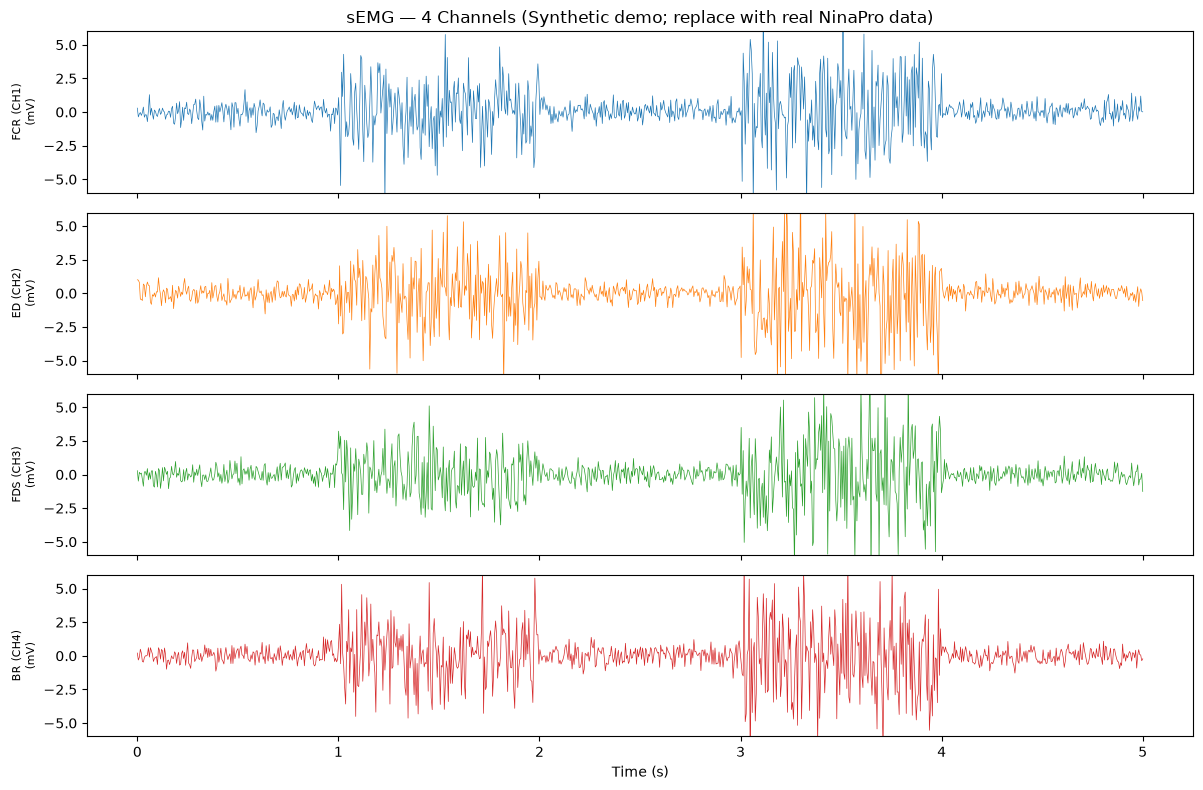

Plot saved.


In [5]:
# ---- Visualise sEMG (run after downloading data) ----
# Replace with: subj = 1; emg, labels, reps = load_subject(subj)

# Synthetic demo of what the plot looks like:
t = np.linspace(0, 5, 1000)
demo_emg = np.random.randn(1000, 4) * 0.5  # noise
# Add fake bursts at different gestures
demo_emg[200:400, :] += np.random.randn(200, 4) * 2  # gesture 1 activation
demo_emg[600:800, :] += np.random.randn(200, 4) * 3  # gesture 2 activation

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
muscles = ['FCR (CH1)', 'ED (CH2)', 'FDS (CH3)', 'BR (CH4)']
for i, (ax, name) in enumerate(zip(axes, muscles)):
    ax.plot(t, demo_emg[:, i], lw=0.5, color=f'C{i}')
    ax.set_ylabel(f'{name}\n(mV)', fontsize=8)
    ax.set_ylim(-6, 6)
axes[-1].set_xlabel('Time (s)')
axes[0].set_title('sEMG — 4 Channels (Synthetic demo; replace with real NinaPro data)')
plt.tight_layout()
plt.savefig('../data/processed/demo_semg_plot.png', dpi=150)
plt.show()
print('Plot saved.')